In [1]:
import math
import meep as mp
from meep import mpb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Lattice Geometry Setting

In [2]:
a = 1                                   # Lattice constant          [um]
r = 0.667*a/2                           # Hole radius               [um]

#lattice vector parameter (PhC)

b1_x_PhC = a
b1_y_PhC = 0
b2_x_PhC = a/2
b2_y_PhC = b2_x_PhC*math.sqrt(3)


## Describing the lattice using lattice vector

In [3]:
X0 = 0      #hole position x
Y0 = 0      #hole position y

## Building PhC geometry & setting k vector positions

In [4]:
Refractive_index = 2.9
eps = Refractive_index**2 #background material properties (Silicon)
default_material = mp.Medium(epsilon=eps)

geometry_lattice = mp.Lattice(size=mp.Vector3(1,1),
                            basis1=mp.Vector3(b1_x_PhC,b1_y_PhC),
                            basis2=mp.Vector3(b2_x_PhC,b2_y_PhC),)

geometry = [
    mp.Cylinder(
        r,
        center=mp.Vector3(X0,Y0),
        material=mp.air,
    ),
]

k_points = [mp.Vector3(0,0,0),          # Gamma
            mp.Vector3(0,0.5,0),        # M            
            mp.Vector3(-1/3,1/3,0),     # K
            mp.Vector3(0,0,0)]          # Gamma

k_interp = 20; # 对k波矢进行插值

k_points = mp.interpolate(k_interp, k_points)


## Solver configuration

In [5]:
resolution = 100
num_bands = 3

ms = mpb.ModeSolver(num_bands=num_bands,
                    k_points=k_points,
                    geometry=geometry,
                    geometry_lattice=geometry_lattice,
                    default_material=default_material,
                    resolution=resolution)

## Run and plot results

In [6]:
ms.run_te()

Initializing eigensolver data
Computing 3 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 100 x 100 x 1.
Solving for 3 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0.5, 0.866025, 0)
     (0, 0, 1)
Cell volume = 0.866025
Reciprocal lattice vectors (/ 2 pi):
     (1, -0.57735, 0)
     (-0, 1.1547, -0)
     (0, -0, 1)
Geometric objects:
     cylinder, center = (0,0,0)
          radius 0.3335, height 1e+20, axis (0, 0, 1)
Geometric object tree has depth 1 and 1 object nodes (vs. 1 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: te.
Initializing fields to random numbers...
64 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.0, 0.023809523809523808, 0.0>
  Vector3<0.0, 0.047619047619047616, 0.0>
  Vector3<0.0, 0.07142857142857142, 0.0>
  Vector3<0.0, 0.09523809523809523, 0.0>
  Vector3<0.0, 0.11904761904761904, 0.0>
  Vector3<0.0, 0.14285714285714285, 0.0>
  Vector3<0.0, 0.16

epsilon: 1-8.41, mean 5.42029, harm. mean 2.1383, 61.23% > 1, 59.653% "fill"
real part range: 1 .. 8.41


[Text(0.0, 0, 'Γ'), Text(21.0, 0, 'M'), Text(42.0, 0, 'K'), Text(63.0, 0, 'Γ')]

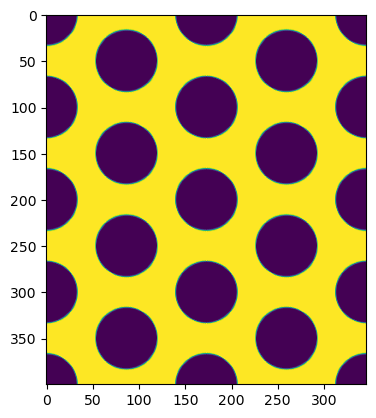

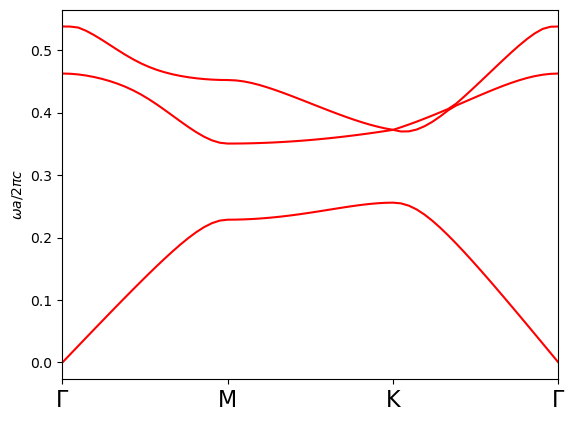

In [7]:
te_freqs = ms.all_freqs
te_gaps = ms.gap_list

material_settings = ms.output_mu

eps = ms.get_epsilon() # 得到折射率分布
md = mpb.MPBData(rectify=True, resolution=100, periods=4)
converted_eps = md.convert(eps) 

plt.figure()
plt.imshow(converted_eps)

numk,tmp=np.shape(te_freqs)
klist=range(numk)

fig,ax=plt.subplots()
x = range(len(te_freqs))

for l in range(num_bands):
    plt.plot(te_freqs[:,l],'r-')
    
plt.xlim([0,63])
plt.ylabel('$\omega a/2\pi c$')

points_in_between = (len(te_freqs) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(4)]
tick_labs = ['Γ', 'M', 'K', 'Γ']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)


## Photonic crystal defect waveguide settings

In [8]:
supercell_y = a*math.sqrt(3)*8         # supercell in y direction  [um]
supercell_x = a                         # supercell in x direction  [um]

dx = a*0.5
dy = a*math.sqrt(3)
#lattice vector parameter (PCW)

b1_x_PCW = supercell_x        # [um]
b1_y_PCW = 0
b2_x_PCW = 0
b2_y_PCW = supercell_y        # [um]

#设计参数
W1 = (a*math.sqrt(3))

Y_layer_number = int(np.round((supercell_y/dy)/2))

# triangular lattice with vertical supercell:
geometry_lattice_PCW = mp.Lattice(
    size=mp.Vector3(supercell_x, supercell_y),
    basis1=mp.Vector3(b1_x_PCW, b1_y_PCW),
    basis2=mp.Vector3(b2_x_PCW, b2_y_PCW),
)

geometry_PCW = []

geometry_slab = [mp.Block(size=mp.Vector3(supercell_x, supercell_y), center=mp.Vector3(),material=default_material),]

geometry_PCW = geometry_PCW + geometry_slab



print(Y_layer_number)

for i in range(Y_layer_number): 
    x_A_up = -dx
    y_A_up = (W1/2)+(dy*i)
    x_B_up = 0
    y_B_up = (W1/2)+(dy*i)+(dy*0.5)
    x_C_up = dx
    y_C_up = (W1/2)+(dy*i)
    
    geometry_A = [mp.Cylinder(radius=r, center=mp.Vector3(x_A_up,y_A_up), material=mp.air)]
    geometry_B = [mp.Cylinder(radius=r, center=mp.Vector3(x_B_up,y_B_up), material=mp.air)]
    geometry_C = [mp.Cylinder(radius=r, center=mp.Vector3(x_C_up,y_C_up), material=mp.air)]
    
    Geo_PCW = geometry_A+geometry_B+geometry_C
    
    geometry_PCW = geometry_PCW+Geo_PCW
    
for i in range(Y_layer_number): 
    x_A_down = -dx
    y_A_down = -(W1/2)-(dy*i)
    x_B_down = 0
    y_B_down = -(W1/2)-(dy*i)-(dy*0.5)
    x_C_down = -dx
    y_C_down = -(W1/2)-(dy*i)
    geometry_A = [mp.Cylinder(radius=r, center=mp.Vector3(x_A_down,y_A_down), material=mp.air)]
    geometry_B = [mp.Cylinder(radius=r, center=mp.Vector3(x_B_down,y_B_down), material=mp.air)]
    geometry_C = [mp.Cylinder(radius=r, center=mp.Vector3(x_C_down,y_C_down), material=mp.air)]
    
    Geo_PCW = geometry_A+geometry_B+geometry_C
    
    geometry_PCW = geometry_PCW+Geo_PCW

4


## Check materials and run simulation

In [9]:
k_points_PCW = [mp.Vector3(0,0),mp.Vector3(0.5,0)]      
k_interp_PCW = 10 # 对k波矢进行插值

k_points_PCW = mp.interpolate(k_interp_PCW, k_points_PCW)

resolution_PCW = 10

num_bands_PCW = 40

ms = mpb.ModeSolver(
    geometry_lattice=geometry_lattice_PCW,
    default_material=mp.air,
    geometry=geometry_PCW,
    resolution=resolution_PCW,
    num_bands=num_bands_PCW,
    k_points=k_points_PCW,
)


In [10]:
ms.run_zeven()

Initializing eigensolver data
Computing 40 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 10 x 140 x 1.
Solving for 10 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 13.8564, 0)
     (0, 0, 1)
Cell volume = 13.8564
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.0721688, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,13.8564,0)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (-0.5,0.866025,0)
          radius 0.3335, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0,1.73205,0)
          radius 0.3335, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.5,0.866025,0)
          radius 0.3335, height 1e+20, axis (0, 0, 1)
     cylinder, center = (-0.5,2.59808,0)
          radius 0.3335, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0,3.4641,0)
          radius 0.3335, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.5,2.598

epsilon: 1-8.41, mean 5.60716, harm. mean 2.59742, 75.5% > 1, 62.1749% "fill"


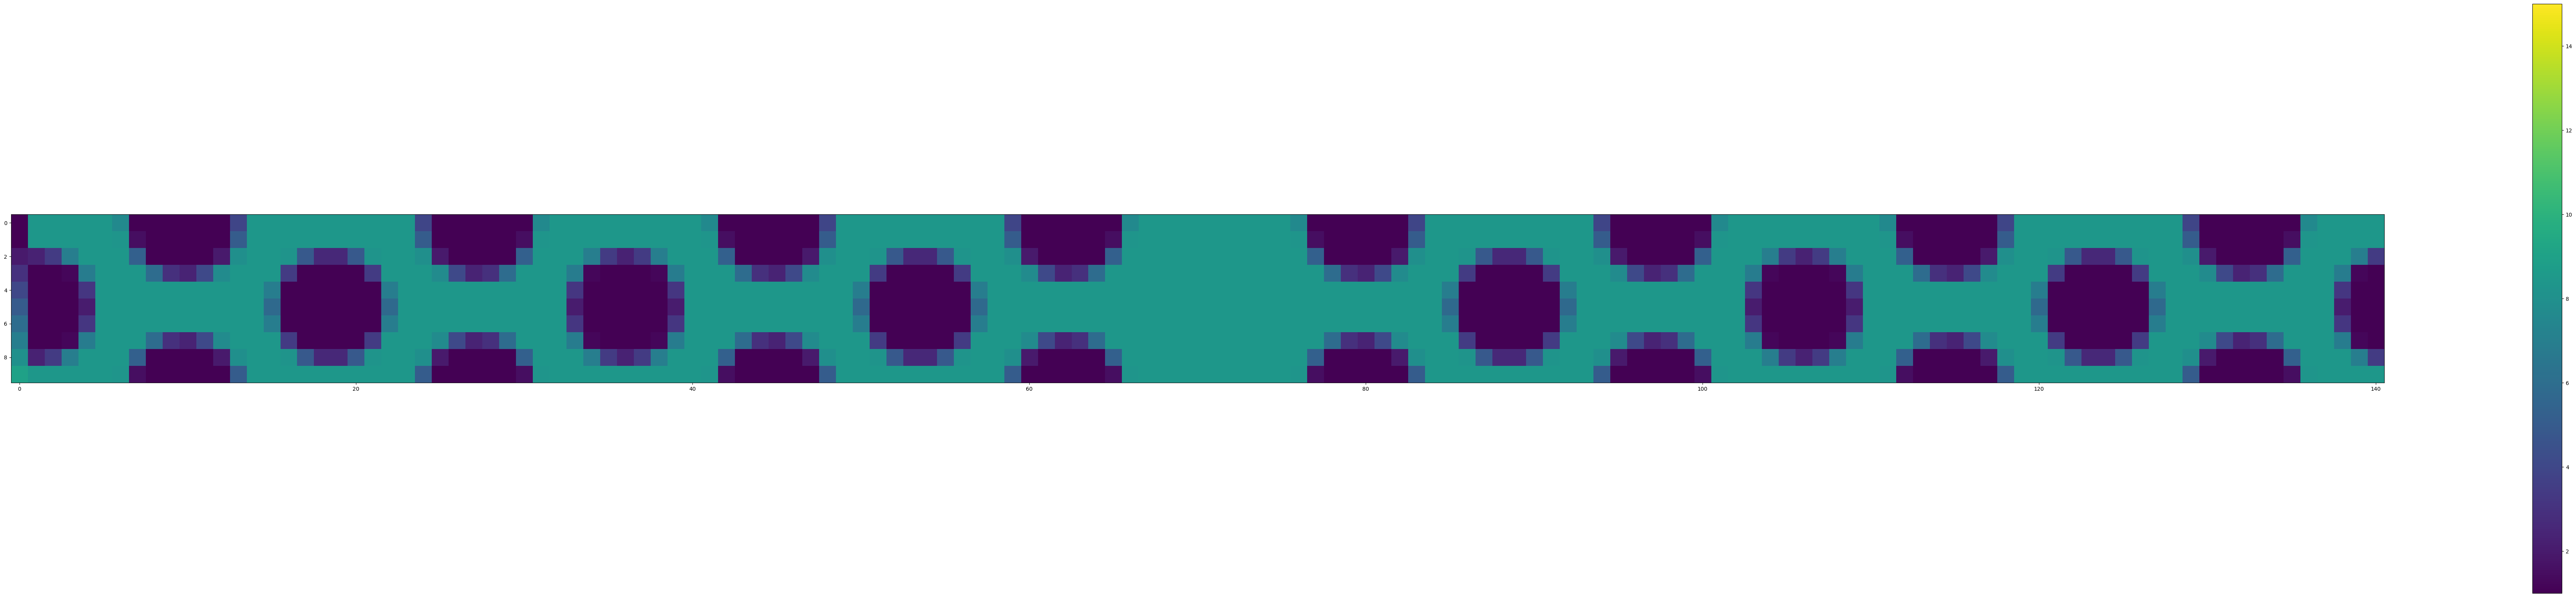

In [11]:
Material=ms.get_epsilon()
Export_Material = Material[:,:]

data = pd.DataFrame(Export_Material)
data.to_csv('Material_xy.csv')

Material = pd.read_csv('Material_xy.csv')

plt.figure(figsize = (100,20))
# plt.imshow(Field,vmin=-7,vmax=7,cmap='hot')
plt.imshow(Material,vmin=1,vmax=15)

plt.colorbar()
    

numk =  12
tmp =  40


Text(0.5, 0, '$Wavevector: k$')

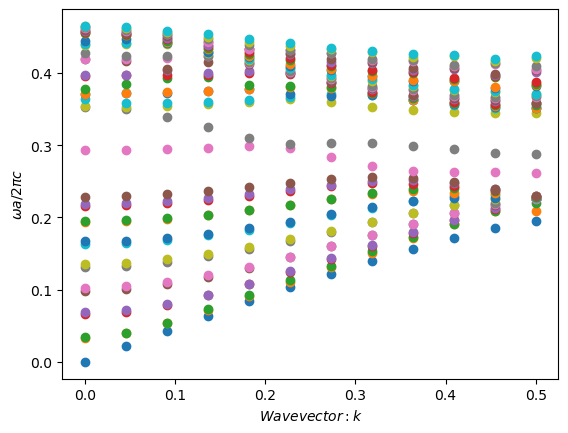

In [12]:
te_freqs = ms.all_freqs

numk,tmp=np.shape(te_freqs)

print("numk = ",numk)
print("tmp = ",tmp)

k_axis = np.linspace(0,0.5,numk)

for l in range(tmp):
    plt.scatter(k_axis,te_freqs[:,l])
plt.ylabel('$\omega a/2\pi c$')
plt.xlabel('$Wavevector: k$')
# plt.ylim([0.22,0.38])
# plt.xlim([0,0.5])


## Checking light field distribution

Initializing eigensolver data
Computing 40 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 100 x 1400 x 1.
Solving for 10 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 13.8564, 0)
     (0, 0, 1)
Cell volume = 13.8564
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 0.0721688, -0)
     (0, -0, 1)
Geometric objects:
     block, center = (0,0,0)
          size (1,13.8564,0)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (-0.5,0.866025,0)
          radius 0.3335, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0,1.73205,0)
          radius 0.3335, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.5,0.866025,0)
          radius 0.3335, height 1e+20, axis (0, 0, 1)
     cylinder, center = (-0.5,2.59808,0)
          radius 0.3335, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0,3.4641,0)
          radius 0.3335, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.5,2.5

Text(0.5, 0, '$Wavevector: k$')

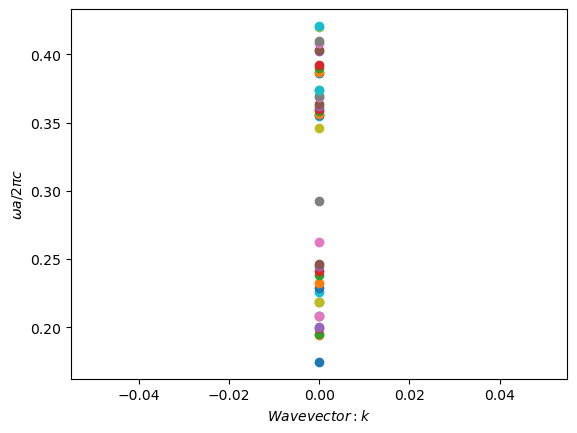

In [44]:
k_points_PCW_single_point = [mp.Vector3(0.42,0)]      

ms = mpb.ModeSolver(
    geometry_lattice=geometry_lattice_PCW,
    default_material=mp.air,
    geometry=geometry_PCW,
    resolution=100,
    num_bands=num_bands_PCW,
    k_points=k_points_PCW_single_point,
)

ms.run_zeven()

te_freqs = ms.all_freqs

numk,tmp=np.shape(te_freqs)

print("numk = ",numk)
print("tmp = ",tmp)

k_axis = np.linspace(0,0.5,numk)

for l in range(tmp):
    plt.scatter(k_axis,te_freqs[:,l])
plt.ylabel('$\omega a/2\pi c$')
plt.xlabel('$Wavevector: k$')



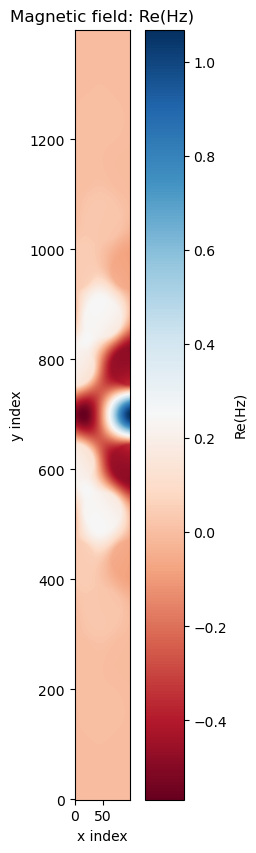

In [45]:
fields = ms.get_hfield(17)
# fields = ms.get_hfield(17)

Hz = fields[:, :, 0, 2]

plt.figure(figsize=(4, 10))
plt.imshow(np.real(Hz).T, origin="lower", cmap="RdBu")
plt.colorbar(label="Re(Hz)")
plt.xlabel("x index")
plt.ylabel("y index")
plt.title("Magnetic field: Re(Hz)")
plt.show()

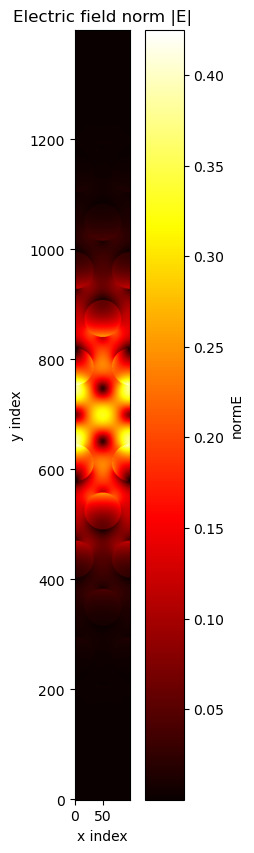

In [46]:
fields = ms.get_efield(17)

Ex = fields[:, :, 0, 0]
Ey = fields[:, :, 0, 1]
Ez = fields[:, :, 0, 2]

normE = np.sqrt(np.abs(Ex)**2 + np.abs(Ey)**2 + np.abs(Ez)**2)

plt.figure(figsize=(4, 10))
plt.imshow(normE.T, origin="lower", cmap="hot")
plt.colorbar(label="normE")
plt.xlabel("x index")
plt.ylabel("y index")
plt.title("Electric field norm |E|")
plt.show()